# AAI614: Data Science & its Applications

*Notebook 4.1: Graph Analytics with cuGraph and TIGER*

<a href="https://colab.research.google.com/github/harmanani/AAI614/blob/main/Week%204/Notebook4.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>




The study of network robustness is critical to the understanding of complex interconnected systems. For example, consider an example of a power grid network that is susceptible to both natural failures and targeted attacks. A natural failure occurs when a single power substation fails due to erosion of parts or natural disasters. However, when one substation fails, additional load is routed to alternative substations, potentially causing a series of cascading failures. Not all failures originate from natural causes, some come from targeted attacks, such as enemy states hacking into the grid to sabotage key equipment to maximally damage the operations of the electrical grid. A natural counterpart to network robustness is vulnerability, defined as measure of a network’s susceptibility to the dissemination of entities across the network, such as how quickly a virus spreads across a computer network.

In this lab, we show how to use [cuGraph](https://github.com/rapidsai/cugraph) and [TIGER](https://github.com/safreita1/TIGER) to conduct state-of-the-art GPU accelerated graph vulnerability and robustness analysis. Specifically, we will look at how to:

- *Quantify network vulnerability and robustness* (**Part 1**),
- *Simulate network attacks and cascading failures on networks* (**Part 2**)
- *Regulate the dissemination of computer virues on a network* (**Part 3**)

Lab Source: **NVIDIA**

## Setup
Lets begin by installing the following 2 libraries:

1.   Graph vulnerability and robustness analysis library: [TIGER](https://github.com/safreita1/TIGER)
2.   GPU acceleration library: [CuPy](https://github.com/cupy/cupy)


In [22]:
!rm -rf rapidsai-csp-utils

In [ ]:
!bash rapidsai-csp-utils/colab/update_gcc.sh
import os
os._exit(0)

Updating your Colab environment.  This will restart your kernel.  Don't Panic!
Found existing installation: cupy-cuda12x 13.6.0
Uninstalling cupy-cuda12x-13.6.0:


In [23]:
import sys

# 1. Install stopit (usually easy)
!pip install stopit

# 2. Install graph-tiger (usually easy)
!pip install graph-tiger

In [1]:
!pip install -q condacolab
import condacolab
condacolab.install()

⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:10
🔁 Restarting kernel...


In [24]:
import sys

# Add the path where graph-tiger is actually installed
path_to_311 = '/usr/local/lib/python3.11/site-packages'
if path_to_311 not in sys.path:
    sys.path.append(path_to_311)

# Now try the imports again
from graph_tiger.measures import run_measure
from graph_tiger.graphs import graph_loader

print("Success! Imports are working.")

Success! Imports are working.


In [2]:
!git clone https://github.com/rapidsai/rapidsai-csp-utils.git
!python rapidsai-csp-utils/colab/env-check.py

Cloning into 'rapidsai-csp-utils'...
remote: Enumerating objects: 629, done.
remote: Counting objects: 100% (195/195), done.
remote: Compressing objects: 100% (110/110), done.
remote: Total 629 (delta 149), reused 86 (delta 85), pack-reused 434 (from 3)
Receiving objects: 100% (629/629), 207.69 KiB | 17.31 MiB/s, done.
Resolving deltas: 100% (323/323), done.
***********************************************************************
Woo! Your instance has the right kind of GPU, a Tesla T4!
We will now install RAPIDS via pip!  Please stand by, should be quick...
***********************************************************************



In [ ]:
# Install RAPIDS
!git clone https://github.com/rapidsai/rapidsai-csp-utils.git
!bash rapidsai-csp-utils/colab/rapids-colab.sh stable

import sys, os

dist_package_index = sys.path.index('/usr/local/lib/python3.7/dist-packages')
sys.path = sys.path[:dist_package_index] + ['/usr/local/lib/python3.7/site-packages'] + sys.path[dist_package_index:]
sys.path
exec(open('rapidsai-csp-utils/colab/update_modules.py').read(), globals())

In [1]:
!python rapidsai-csp-utils/colab/install_rapids.py stable
import os
os.environ['NUMBAPRO_NVVM'] = '/usr/local/cuda/nvvm/lib64/libnvvm.so'
os.environ['NUMBAPRO_LIBDEVICE'] = '/usr/local/cuda/nvvm/libdevice/'
os.environ['CONDA_PREFIX'] = '/usr/local'

Found existing installation: cffi 1.17.1
Uninstalling cffi-1.17.1:
  Successfully uninstalled cffi-1.17.1
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for cffi: filename=cffi-1.15.0-cp311-cp311-linux_x86_64.whl size=185195 sha256=e56045da28ba3bd279df4141311adc81e41f6a6b82dd649c9187cfc591bd6e30
  Stored in directory: /root/.cache/pip/wheels/12/f5/09/5baf6dde29553c4804a3ce1adfd4f1815e136fc19644deb92a
Successfully built cffi
Installing RAPIDS Stable 23.12
Starting the RAPIDS install on Colab.  This will take about 15 minutes.
Channels:
 - conda-forge
Platform: linux-64
Solving environment: ...working... done

## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - mamba


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    c-ares-1.34.6              |       hb03c661_0         203 KB  conda-fo

That's it! Now we can run a variety of GPU acclerated graph mining algorithms.



## Part 1: Quantifing network vulnerability and robustness

While CPU calculations work well for sparse graphs, GPU acceleration significantly speeds-up analysis for dense graphs. To see this, lets run the code below that measures the robustness of a Barabási Albert (BA) graph at varying levels of density (i.e., number of edges per node).

In [7]:
import time
from tqdm import tqdm

from graph_tiger.measures import run_measure
from graph_tiger.graphs import graph_loader

# controls graph density by varying the number of non-zeroes per row (i.e., number of edges per node in graph)
nnz_per_row = list(range(50, 501, 50))

cpu_times = []
gpu_times = []
for nnz in tqdm(nnz_per_row):
  graph = graph_loader(graph_type='BA', n=1000, m=nnz, seed=1)

  start_cpu = time.time()
  robustness_index = run_measure(graph, measure='average_vertex_betweenness', k=int(0.05 * len(graph)))
  end_cpu = time.time()

  start_gpu = time.time()
  robustness_index = run_measure(graph, measure='average_vertex_betweenness', k=12, use_gpu=True)  # ****** Replace with cuGraph version: https://docs.rapids.ai/api/cugraph/stable/api.html#module-cugraph.centrality.betweenness_centrality ******
  end_gpu = time.time()


  cpu_times.append(round(end_cpu - start_cpu, 2))
  gpu_times.append(round(end_gpu - start_gpu, 2))




100%|██████████| 10/10 [00:35<00:00,  3.56s/it]


Now lets plot the results (lower is better).

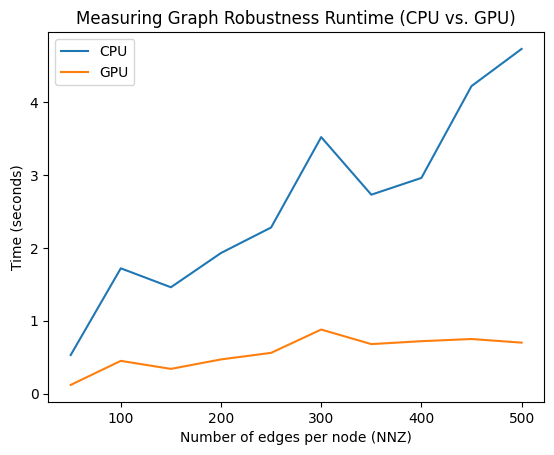

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.plot(nnz_per_row, cpu_times, label='CPU')
plt.plot(nnz_per_row, gpu_times, label='GPU')
plt.xlabel('Number of edges per node (NNZ)')
plt.ylabel('Time (seconds)')
plt.title('Measuring Graph Robustness Runtime (CPU vs. GPU)')
plt.legend()
plt.show()

## Part 2. Simulating Cascading Failures in U.S. Electrical Grid
Cascading failures often arise as a result of natural failures or targeted attacks in a network. There are 3 main processes governing the network simulation:

- the **capacity** of each node (<img src="https://render.githubusercontent.com/render/math?math=c_v">) in the network, e.g., power substation capacity.

- the **load** of each node (<img src="https://render.githubusercontent.com/render/math?math=l_v">) in the network, e.g., power substation load level

- network **redundancy** (*r*) representing the amount of reserve capacity present in the network i.e., auxiliary support systems.

When a node is attacked it becomes "overloaded", causing it to fail and requiring the load be distributed to its neighbors. When defending a node, we increase it’s capacity to protect against attacks. With just these 3 parameters, we can setup a cascading failure simulation. Below, we show how to load a graph representing the U.S. electrical grid and setup the simulation parameters.

In [9]:
from graph_tiger.graphs import graph_loader

graph = graph_loader('electrical')

params = {
   'runs': 1,  # number of times to run the simulation
   'steps': 100,  # number of time steps to run each simulation
   'seed': 1,  # for repoducibility

   'l': 0.8,  # network load [0, 1]
   'r': 0.2,  # network redundancey [0, 1]
   'c': int(0.1 * len(graph)),  # load capacity approximation

   'robust_measure': 'largest_connected_component',  # measure of network health
}

### Setting up a Targeted Attack
To run the attack we just have to modify a few simulation parameters. We set the attack to remove 30 nodes in the graph (e.g., power grid substations) with highest degree centrality "id_node". As you can imagine, there are many different strategies that can be used to attack the grid, however, by selecting degree centrality we can find "central" nodes in the network with many power lines (edges) connected to the substations (nodes).

In [10]:
params.update({
   'k_a': 30,  # number of nodes to attack
   'attack': 'id_node',  # attack strategy
})

Now lets run the simulation and plot the results!

In [13]:
import sys
from unittest.mock import MagicMock

# A list of all the "stubborn" visualization dependencies
modules_to_mock = ["fa2", "datashader", "datashader.bundling"]

for module in modules_to_mock:
    sys.modules[module] = MagicMock()

# Now try the import again
try:
    from graph_tiger.cascading import Cascading
    print("Success! Cascading is imported and ready for simulation.")
except Exception as e:
    print(f"Still hitting a snag: {e}")

Success! Cascading is imported and ready for simulation.


In [14]:
import sys
from unittest.mock import MagicMock

# Create a 'fake' fa2 module so graph_tiger doesn't crash
mock_fa2 = MagicMock()
sys.modules["fa2"] = mock_fa2

# Now import Cascading
from graph_tiger.cascading import Cascading
print("Cascading imported successfully by bypassing fa2!")

Cascading imported successfully by bypassing fa2!


Running simulation 1 times
Simulation completed successfully!


<Figure size 640x480 with 0 Axes>

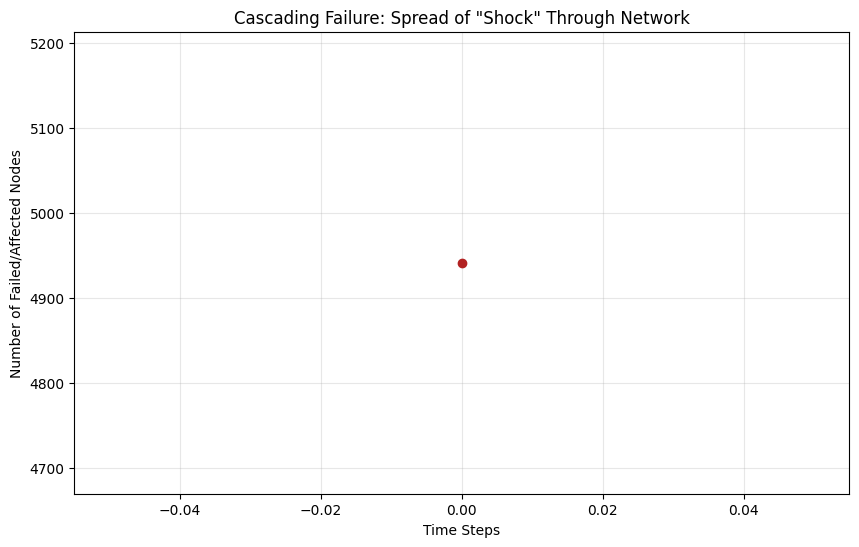

In [19]:
import networkx as nx
import scipy.sparse

# Bridge the version gap: Map the old name to the new function
if not hasattr(nx, 'to_scipy_sparse_matrix'):
    nx.to_scipy_sparse_matrix = nx.to_scipy_sparse_array

# Now try to run your simulation
from graph_tiger.cascading import Cascading

cascading = Cascading(graph, **params)
results = cascading.run_simulation()

print("Simulation completed successfully!")
cascading.plot_results(results)

import matplotlib.pyplot as plt

# results is usually a list of lists (one per simulation run)
# We take the first (and only) run
cascade_data = results[0]

plt.figure(figsize=(10, 6))
plt.plot(cascade_data, marker='o', linestyle='-', color='firebrick')
plt.title('Cascading Failure: Spread of "Shock" Through Network')
plt.xlabel('Time Steps')
plt.ylabel('Number of Failed/Affected Nodes')
plt.grid(True, alpha=0.3)
plt.show()

### 1. Collapsing a network

Now try modifying the code to find the minimal attack necessary to collapse the electrical grid. To do this, plot the "health" of the network as measured by the robustness measure (i.e., "largest_connected_component") at the end of each simulation, against the attack strength ("k_a").

**Hint:** electrical networks are fragile to targeted attacks, try removing just a few nodes.

  0%|          | 0/6 [00:00<?, ?it/s]

Running simulation 1 times


 17%|█▋        | 1/6 [00:20<01:40, 20.14s/it]

Running simulation 1 times


 33%|███▎      | 2/6 [00:39<01:18, 19.51s/it]

...

Running simulation 1 times


 83%|████████▎ | 5/6 [01:39<00:19, 19.85s/it]

Running simulation 1 times


100%|██████████| 6/6 [01:59<00:00, 19.97s/it]


Text(0.5, 1.0, 'Effect of Attack Strength in Cascading Failures')

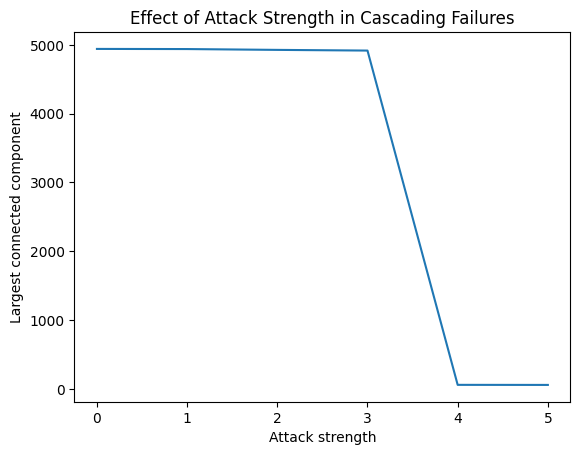

In [18]:
sim_results =[]

params['attack'] = 'id_node'
attack_strengths = list(range(0, 6, 1))

for k_a in tqdm(attack_strengths):
  params['k_a'] = k_a

  cascading = Cascading(graph, **params)
  results = cascading.run_simulation()

  lcc_at_end = results[-1]
  sim_results.append(lcc_at_end)

%matplotlib inline
import matplotlib.pyplot as plt

plt.plot(attack_strengths, sim_results)
plt.xlabel('Attack strength')
plt.ylabel('Largest connected component')
plt.title('Effect of Attack Strength in Cascading Failures')

# Part 3. Simulating Computer Virus Spread Across Router Network

The flu-like susceptible-infected-susceptible (SIS) is a popular model that allows us to simulate the spread of viruses across networks (graphs). Each node in the SIS model can be in one of two states, infected *I* or susceptible *S*, and at each time step *t*, an infected node has a probability *β* of infecting each of it's uninfected neighbors. After this, each infected node has a probability *δ* of healing and becoming susceptible again.

It’s been shown there's a direct correlation between the graph's topology as measured through the spectral radius (largest eigenvalue) of the graph, and the virus remaining endemic. The exact relationship between a virus's strength (*s*), birth rate (*β*), death rate (*δ*) and spectral radius (*λ1*) is s=λ1⋅b/d, where a larger *s* means a stronger virus. With just these 3 parameters, we can setup a computer virus simulation.

Below, we (1) load the Autonomous systems AS-733 network, which is a graph of routers comprising the internet; and (2) setup the simulation parameters.  

In [20]:
from graph_tiger.graphs import graph_loader

graph = graph_loader('as_733')

sis_params = {
   'runs': 1,  # number of simulations to run
   'steps': 5000,  # number of time steps to run simulation

   'model': 'SIS',
   'b': 0.00208,  # virus birth rate
   'd': 0.01,  # virus death rate
   'c': 0.3,  # fraction of the network that starts infected
}

Now lets run the simulation and plot the results! In the figure below, we see that without intervention the virus remains endemic on the router network.

In [21]:
from graph_tiger.diffusion import Diffusion
import numpy as np
import networkx as nx

# 1. Fix the NumPy 'float' error
if not hasattr(np, 'float'):
    np.float = float

# 2. Re-ensure the NetworkX 'matrix' error is fixed (from previous step)
if not hasattr(nx, 'to_scipy_sparse_matrix'):
    nx.to_scipy_sparse_matrix = nx.to_scipy_sparse_array

# Now try to plot again

diffusion = Diffusion(graph, **sis_params)
results = diffusion.run_simulation()

diffusion.plot_results(results)

Running simulation 1 times


AttributeError: module 'numpy' has no attribute 'float'.
`np.float` was a deprecated alias for the builtin `float`. To avoid this error in existing code, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
The aliases was originally deprecated in NumPy 1.20; for more details and guidance see the original release note at:
    https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations

<Figure size 640x480 with 0 Axes>

While we do not have control over the virus strength (*s*), we can maniuplate the underlying toplogy of the router network to make it harder for the virus to spread. The question is, how do we optimally modify the network to reduce the spread of the virus? While a naive solution may be to disconnect the whole network, this isn't very practical since everyone would loose internet access! Instead, we need a strategy that carefully vaccinates a few nodes (routers) against the virus.

### 2. Optimally Vaccinating a Network

Now lets compare the efficacy of 4 vaccination strategies when vaccinating only 3 nodes in the network:

1. [netshield](https://graph-tiger.readthedocs.io/en/latest/defenses.html#graph_tiger.defenses.get_node_ns) ('ns_node')
2. [id_node](https://graph-tiger.readthedocs.io/en/latest/defenses.html#graph_tiger.defenses.get_node_id) ('id_node')
2. [rd_node](https://graph-tiger.readthedocs.io/en/latest/defenses.html#graph_tiger.defenses.get_node_rd) ('rd_node')
3. [ib_node](https://graph-tiger.readthedocs.io/en/latest/defenses.html#graph_tiger.defenses.get_node_ib) ('ib_node')

To implement a defense strategy you just have to modify a few simulation parameters.

In [ ]:
sis_params.update({
    'diffusion': 'min',  # we want to minimize the ability of the virus to propagate,
    'method': 'ns_node',  # use the Netshield technique
    'k': 15  # vaccinate 5 nodes according the selected strategy
})

Does each strategy manage to contain the virus (i.e., less than 1\% infected population)? Which strategy has the lowest infected population at the end of the simulation? Setup and run each simulation and compare the results to the unvaccinated network.

In [ ]:
methods = ['ns_node', 'id_node', 'rd_node', 'pr_node']

for method in methods:
  sis_params['method'] = method

  diffusion = Diffusion(graph, **sis_params)
  results = diffusion.run_simulation()

  print('Percent of network that remains infected at end of simulation using {} vaccination technique is {}%'.format(method, round((results[-1] / len(graph)) * 100, 2)))
  diffusion.plot_results(results)